## Test class weight's formula

In [1]:
labels  =  {0: "bite", 1: 'drink', 
                2: 'rest', 3: 'utensiling',
                4: 'other', 5: 'unlabeled'}
    

In [3]:
import os
model_loc = "./test/"
os.path.join(model_loc, "model.pt")

'./test/model.pt'

In [239]:
weights = [[] for i in range(6)]

#class_counts =  [13596, 6813, 77656]
class_counts = np.array([ 59174,  25820, 345374])
#class_counts = np.array([29610, 12956, 173030])

class_counts_2/class_counts_1

class_counts = np.array(class_counts*2)
LABEL_NUM = len(class_counts)
total = np.sum(class_counts)
for i in range(LABEL_NUM):
    if class_counts[i] == 0:
        weights[0].append(0)
        weights[1].append(0)
        weights[2].append(0)
        weights[3].append(0)
        weights[4].append(0)
    else:
        weights[0].append(1/LABEL_NUM)
        weights[1].append(total/(class_counts[i] * LABEL_NUM) / np.sum(total/(class_counts[class_counts!=0] * LABEL_NUM)))
        weights[2].append(1/(1+LABEL_NUM*class_counts[i]/total) / np.sum(1/(1+LABEL_NUM*class_counts[class_counts!=0]/total)))
        weights[3].append(1/class_counts[i] / np.sum(1/class_counts[class_counts!=0]))
        weights[4].append(1/class_counts[i]**0.5 / np.sum(1/class_counts[class_counts!=0]**0.5))
        beta = 0.99999
        weights[5].append((1-beta)/(1-beta**class_counts[i])/ np.sum((1-beta)/(1-beta**class_counts[class_counts!=0])))

weights

[[0.3333333333333333, 0.3333333333333333, 0.3333333333333333],
 [0.2887567575809559, 0.6617696503909949, 0.04947359202804926],
 [0.38291296236233197, 0.45836180890072614, 0.15872522873694192],
 [0.2887567575809559, 0.6617696503909948, 0.04947359202804926],
 [0.34155458427947927, 0.517067764513681, 0.14137765120683982],
 [0.2928590424951282, 0.5037546875907443, 0.2033862699141276]]

In [241]:
sum(class_counts/2)

430368.0

In [231]:
26898*16*2

860736

## Test OpenCV's video framing function

In [ ]:
import cv2
import numpy as np
import sys
import os
import av
import matplotlib.pyplot as plt

#video = cv2.VideoCapture('./CafeteriaData/p005/c2/20120201115555520.asf')

In [2]:
test = './CafeteriaData/p005/c2/20120201115555520.asf'

str.split(test,'/')[-3]

'p005'

In [35]:
video.get(cv2.CAP_PROP_FRAME_COUNT)/video.get(cv2.CAP_PROP_FPS)


767.556

In [27]:
video.set(cv2.CAP_PROP_POS_FRAMES, video.get(cv2.CAP_PROP_FRAME_COUNT))

True

In [49]:
video.get(cv2.CAP_PROP_FRAME_COUNT)

767556.0

In [29]:
video.set(cv2.CAP_PROP_POS_FRAMES, 30*60)
ret, frame = video.read()

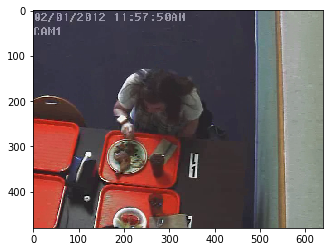

In [22]:
video.get(cv2.CAP_PROP_FRAME_COUNT)

767556.0

In [21]:
video.set(cv2.CAP_PROP_POS_AVI_RATIO,1)
duration = video.get(cv2.CAP_PROP_POS_MSEC)
minute,msec = msec2min(duration)
print
print("{} min {} s".format(minute,msec))

12 min 751.719 s


## Test ffmpeg framing functions

In [121]:
#!ffmpeg -i ./CafeteriaData/p005/c2/20120201115555520.asf -vf fps=6 -hide_banner ./p005_c2/frame_%06d.ppm


Guessed Channel Layout for Input Stream #0.0 : stereo
Input #0, asf, from './CafeteriaData/p005/c2/20120201115555520.asf':
  Metadata:
    WMFSDKNeeded    : 0.0.0.0000
    DeviceConformanceTemplate: @
    WMFSDKVersion   : 12.0.7601.17514
    IsVBR           : 0
  Duration: 00:12:47.56, start: 0.000000, bitrate: 358 kb/s
    Stream #0:0(eng): Audio: wmav2 (a[1][0][0] / 0x0161), 32000 Hz, stereo, fltp, 48 kb/s
    Stream #0:1(eng): Video: wmv2 (WMV2 / 0x32564D57), yuv420p, 640x480, 302 kb/s, 1k tbr, 1k tbn, 1k tbc
Stream mapping:
  Stream #0:1 -> #0:0 (wmv2 (native) -> ppm (native))
Press [q] to stop, [?] for help
Output #0, image2, to './p005_c2/frame_%06d.ppm':
  Metadata:
    WMFSDKNeeded    : 0.0.0.0000
    DeviceConformanceTemplate: @
    WMFSDKVersion   : 12.0.7601.17514
    IsVBR           : 0
    encoder         : Lavf58.29.100
    Stream #0:0(eng): Video: ppm, rgb24, 640x480, q=2-31, 200 kb/s, 6 fps, 6 tbn, 6 tbc
    Metadata:
      encoder         : Lavc58.54.100 ppm
frame=  8

In [54]:
ConvertMsecFormat(1200)

'00:00:01'

In [55]:
import subprocess
def ConvertMsecFormat(msec):
    return "{:02d}:{:02d}:{:02d}".format(int(msec/(60*60*1000)),int(msec%(60*60*1000)/(60*1000)),int(msec%(60*1000)/(1000)))


In [125]:
curVideoPath = "/home/zeyut/eat_detection/CafeteriaData/p005/c2/20120201115555520.asf"

query = "ffprobe -i {} -show_entries format=duration -v quiet -of csv='p=0'".format(curVideoPath)
response = subprocess.Popen(query, shell=True, stdout=subprocess.PIPE).stdout.read()
print(curVideoPath)
print(float(response))
duration = float(response.decode('ascii').split("\n")[0]) *1000

/home/zeyut/eat_detection/CafeteriaData/p005/c2/20120201115555520.asf
767.556


In [124]:
curMsec = 600000
curVideoPath = "/home/zeyut/eat_detection/CafeteriaData/p005/c2/20120201115555520.asf"
frameNo = 3
query = "ffmpeg -y -ss {} -i -hide_banner {} -frames:v 1 frame{:06d}.jpg".format(ConvertMsecFormat(curMsec), \
                                                                   curVideoPath,\
                                                                   frameNo)
response = subprocess.Popen(query, shell=True, stdout=subprocess.PIPE).stdout.read()


In [97]:
print(response)

b''


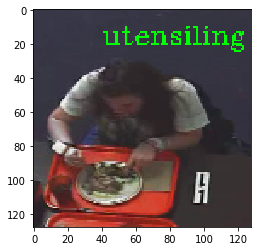

In [15]:
frame = cv2.imread("./p005_c2/frame_004111.ppm",cv2.IMREAD_UNCHANGED)
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
#plt.imshow(frame)

In [ ]:
!ffmpeg -ss 00:05:00 -i ./CafeteriaData/p005/c2/20120201115555520.asf -frames:v 1 out1.jpg


In [39]:
!ffprobe -i ./CafeteriaData/p005/c2/20120201115555520.asf -show_entries format=duration -v quiet -of csv="p=0"

767.556000


In [13]:
fps = video.get(cv2.CAP_PROP_FPS)

timestamps = [video.get(cv2.CAP_PROP_POS_MSEC)]
calc_timestamps = [0.0]

while(video.isOpened()):
    frame_exists, curr_frame = video.read()
    if frame_exists:
        timestamps.append(video.get(cv2.CAP_PROP_POS_MSEC))
        calc_timestamps.append(calc_timestamps[-1] + 1000/fps)
    else:
        break

In [ ]:
for i, (ts, cts) in enumerate(zip(timestamps, calc_timestamps)):
    print('Frame ',ts, ' ',cts)

In [17]:
video.get(cv2.CAP_PROP_POS_MSEC)/60

200.2

In [177]:
import av
import numpy as np
v = av.open('./CafeteriaData/p053/c1/20120222112845996.asf')
for packet in video.demux(stream):

seek_ret = av.av_seek_frame(v,  1, 100, AVSEEK_FLAG_BACKWARD)

IndentationError: expected an indented block (<ipython-input-177-15d77c754e41>, line 6)

In [193]:
import cv2
import av
import matplotlib.pyplot as plt
video = av.open('./CafeteriaData/p005/c1/20120201113438816.asf')


stream = next(s for s in video.streams if s.type == 'video')



In [194]:
float(stream.duration * stream.time_base)
video.duration/av.time_base

851.221

In [203]:
target_sec = 55
time_base = float(stream.time_base)
target_timestamp = int(target_sec / time_base) + stream.start_time
print(target_timestamp)

55000


In [204]:
count = 0
video.seek(target_timestamp,any_frame=True,backward=True,stream=stream)

for packet in video.demux(stream):
    # Do something with `packet`, often:
    if packet.pts < target_timestamp:
        continue
    else:
        img = packet.decode()[0].to_ndarray(format='bgr24')
        print(packet.decode()[0].time)
        break

55.022


In [179]:
np.unique(img)

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [53]:
# count all the packets
video.seek(-1)

total_packet_count = 0
for packet in video.demux():
    total_packet_count += 1
print(total_packet_count)     
# seek to middle
video.seek(video.duration // 2)
seek_packet_count = 0
for packet in video.demux():
    seek_packet_count += 1
print(seek_packet_count)                 

17782
8984


### Create Videos with GTs

In [46]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

In [60]:
video_idx = "p176_c1"
source_loc = "/scratch1/zeyut/eat_detection/VideoData_torch_224/{}/".format(video_idx)
#source_loc = "/home/zeyut/eat_detection/workspace/eating-gesture-detection/VideoData/{}/".format(video_idx)
try:
    os.mkdir("./{}".format(video_idx))
except:
    pass

min_num = 0
gt = open("{}gt_frame_3labels.txt".format(source_loc),"r")
for line in gt.readlines():
    image_name = line.split("\t")[0]
    label = line.split("\t")[1].split("\n")[0]
    raw = cv2.imread("{}{}".format(source_loc,image_name),cv2.IMREAD_UNCHANGED)
    output = cv2.putText(raw, label,(40,20),cv2.FONT_HERSHEY_COMPLEX,0.5,(0,255,0))
    cv2.imwrite("./{}/{}".format(video_idx,image_name),output)
    
    if not min_num:
        min_num = int(image_name[6:12])
print(min_num)

11


In [61]:
!ffmpeg -start_number 11 -i ./p17222222222226_c1/frame_%06d.ppm -vcodec mpeg4 p176_c1.avi
#!ffmpeg -i ./data/test/frame%05d.ppm -vcodec mpeg4 test.avi 

ffmpeg version 4.2.2 Copyright (c) 2000-2019 the FFmpeg developers
  built with gcc 8 (GCC)
  configuration: --prefix=/software/spackages/linux-centos8-x86_64/gcc-8.3.1/ffmpeg-4.2.2-npmqim7wt2vachtm6j44df33tb4dbmoz --enable-pic --cc=/software/spack-src/develop/lib/spack/env/gcc/gcc --cxx=/software/spack-src/develop/lib/spack/env/gcc/g++ --disable-libxcb --disable-libxcb-shape --disable-libxcb-shm --disable-libxcb-xfixes --disable-xlib --disable-libfontconfig --disable-libfreetype --disable-libfribidi --enable-bzlib --disable-libmp3lame --disable-libopenjpeg --disable-libopus --disable-libspeex --disable-libvorbis --disable-avresample --disable-openssl --enable-shared --disable-libzmq --disable-libssh --disable-libwebp --disable-lzma --disable-libsnappy --disable-sdl2 --disable-libaom
  libavutil      56. 31.100 / 56. 31.100
  libavcodec     58. 54.100 / 58. 54.100
  libavformat    58. 29.100 / 58. 29.100
  libavdevice    58.  8.100 / 58.  8.100
  libavfilter     7. 57.100 /  7. 57.100


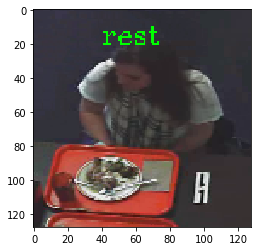

In [18]:
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))

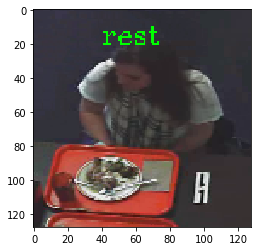

In [18]:
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))

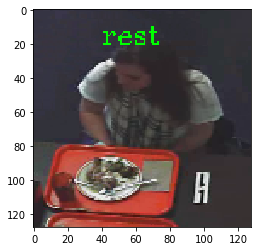

In [18]:
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))

## Create Videos with GTs and Predictions

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import multiprocessing
from multiprocessing import Pool
import subprocess

In [2]:
LABEL_TABLE = ["bite", "drink", "NI"]

def process_results(video_idx):
    global result_loc
    min_num = 0
    results = open("{}pred_{}.txt".format(result_loc,video_idx),"r")
    confusion_matrix = np.zeros((3,3))
    TP = [0,0,0]
    P = [0,0,0]
    for line in results.readlines():
        image_name = line.split("\t")[0]
        label = line.split("\t")[1]
        pred = line.split("\t")[2].split("\n")[0]

        TP[int(label)] += int(pred == label)
        P[int(label)] += 1
        confusion_matrix[int(pred)][int(label)] += 1
        if not min_num:
            min_num = int(image_name[6:12])
    return TP, P, min_num, confusion_matrix

In [3]:
LABEL_TABLE = ["bite", "drink", "NI"]

def make_frames(video_idx):
    global source_loc,result_loc,save_loc
    try:
        os.mkdir("{}{}".format(save_loc,video_idx))
    except:
        pass
    results = open("{}pred_{}.txt".format(result_loc,video_idx),"r")
    for line in results.readlines():
        image_name = line.split("\t")[0]
        label = line.split("\t")[1]
        pred = line.split("\t")[2].split("\n")[0]
        #print(label,pred)
        raw = cv2.imread("{}{}/{}".format(source_loc,video_idx,image_name),cv2.IMREAD_UNCHANGED)
        output = cv2.putText(raw, "GT:{}".format(LABEL_TABLE[int(label)]),(20,20),cv2.FONT_HERSHEY_COMPLEX,0.5,(0,255,0))
        output = cv2.putText(output, "P:{}".format(LABEL_TABLE[int(pred)]),(20,40),cv2.FONT_HERSHEY_COMPLEX,0.5,(0,255,0))
        cv2.imwrite("{}/{}/{}".format(save_loc,video_idx,image_name),output)
    print("video {} finished".format(video_idx))

In [4]:
#raw = cv2.imread("/scratch1/zeyut/eat_detection/VideoData/p030_c1/frame_000420.ppm",cv2.IMREAD_UNCHANGED)
#plt.imshow(raw)

In [8]:
#source_loc = "/scratch1/zeyut/eat_detection/VideoData_224by224/"
source_loc = "/scratch1/zeyut/eat_detection/VideoData_independent/test_set/"
#source_loc = "/home/zeyut/eat_detection/workspace/eating-gesture-detection/VideoData/"
#result_loc = "/home/zeyut/eat_detection/workspace/archive/archive_04132021/test_CNNLSTM_Model_30_16_8_300_v2/"
#result_loc = "/home/zeyut/eat_detection/workspace/eating-gesture-detection/test_CNNLSTM_Model_30_16_8_300_v2/"
result_loc = "/scratch1/zeyut/eat_detection/test_RES_LSTM_30_16_8_v3/frame_preds/"
all_TP = []
all_P = []
all_confusion_matrix = np.zeros((3,3))
filelist = [f[5:-4] for f in os.listdir(result_loc) if f.startswith("pred")]
#filelist = ["p030_c1","p029_c1","p026_c1","p025_c1"]
#filelist = ["p205_c2"]
#filelist = ["p207_c3","p176_c1","p179_c3","p177_c2","p176_c2"]
#filelist = ["p176_c1"]
min_frame_nums = [] 
for video_idx in filelist:
    TP, P, min_num,confusion_matrix = process_results(video_idx)
    min_frame_nums.append(min_num)
    #print(min_num)
    all_TP.append(TP)
    all_P.append(P)
    all_confusion_matrix += confusion_matrix
all_TP = np.array(all_TP)
all_P = np.array(all_P)


In [9]:
np.mean(np.sum(all_TP,axis=0) / np.sum(np.clip(all_P,1,None),axis=0))


0.804431212541539

In [10]:
a = np.array([[1,2,3],[4,5,6]])
a = np.expand_dims(a, axis=-1)

np.concatenate([a,a,a],axis=-1)

array([[[1, 1, 1],
        [2, 2, 2],
        [3, 3, 3]],

       [[4, 4, 4],
        [5, 5, 5],
        [6, 6, 6]]])

#
p023_c1,p151_c2,p125_c1,p173_c1,p103_c1,p034_c2,

In [12]:
print("Video\tBite\tDrink\tOthers\tStart frame")
bad_videos = []
start_frames = []
for i,j,k in zip(filelist, all_TP / all_P,min_frame_nums):
    if any(j < 1):
        print("{0}\t{1:.4f}\t{2:.4f}\t{3:.4f}\t{4:d}".format(i,j[0],j[1],j[2],k))
        bad_videos.append(i)
        start_frames.append(k)

Video	Bite	Drink	Others	Start frame
p016_c2	0.9283	0.9633	0.8017	576
p180_c3	0.7722	nan	0.8065	211
p113_c2	0.7747	1.0000	0.8986	15
p188_c1	0.9056	0.8687	0.7978	283
p180_c1	0.7853	0.8988	0.6658	246
p148_c2	0.3466	0.9658	0.9713	223
p105_c1	0.6419	0.9628	0.8858	1646
p113_c1	0.7964	0.7436	0.8880	442
p188_c2	0.7523	1.0000	0.8441	765
p109_c2	0.5388	0.4222	0.9544	1
p186_c2	0.7185	0.9156	0.9398	369
p215_c1	0.4045	0.9967	0.9011	218
p159_c1	0.9119	0.9931	0.8722	1353
p118_c1	0.5079	0.8010	0.9518	819
p215_c3	0.4746	0.9630	0.9561	260
p177_c2	0.0568	nan	0.8483	112
p192_c2	0.6798	0.9498	0.8705	246
p177_c1	0.6003	0.9828	0.8599	587
p186_c1	0.7483	0.8953	0.8495	35
p150_c1	0.6316	0.7675	0.9309	159
p180_c2	0.4297	1.0000	0.6955	155
p025_c1	0.4833	0.9459	0.9346	239
p029_c1	0.5304	0.9803	0.9859	417
p072_c1	0.4750	0.9061	0.9009	13
p148_c1	0.6667	0.8500	0.9238	270
p088_c2	0.8260	1.0000	0.9278	609
p192_c1	0.4571	0.9917	0.8866	258
p033_c1	0.7089	0.9897	0.9512	119
p056_c2	0.7882	0.9759	0.8671	29
p104_c1	0.6368	1.

<ipython-input-12-df424e423083>:4: RuntimeWarning: invalid value encountered in true_divide
  for i,j,k in zip(filelist, all_TP / all_P,min_frame_nums):


In [65]:
print("Video\tBite\tDrink\tOthers\tStart frame")
bad_videos = []
start_frames = []
for i,j,k in zip(filelist, all_TP / all_P,min_frame_nums):
    if any(j < 0.5):
        print("{0}\t{1:.4f}\t{2:.4f}\t{3:.4f}\t{4:d}".format(i,j[0],j[1],j[2],k))
        bad_videos.append(i)
        start_frames.append(k)

Video	Bite	Drink	Others	Start frame
p148_c2	0.3508	0.9684	0.9626	223
p215_c1	0.4083	0.9967	0.8932	218
p177_c2	0.0646	nan	0.8280	112
p180_c2	0.4534	1.0000	0.6809	155
p072_c1	0.4900	0.9096	0.8924	13
p192_c1	0.4837	0.9917	0.8724	258
p047_c2	0.8608	0.0211	0.6400	47
p215_c2	0.3676	0.9933	0.9415	503
p109_c1	0.6567	0.2105	0.9458	465
p118_c2	0.4482	0.5662	0.9467	77


/home/zeyut/.conda/envs/tf-2/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: invalid value encountered in true_divide
  after removing the cwd from sys.path.
/home/zeyut/.conda/envs/tf-2/lib/python3.6/site-packages/ipykernel_launcher.py:5: RuntimeWarning: invalid value encountered in less
  """


In [66]:
start_frames

[223, 218, 112, 155, 13, 258, 47, 503, 465, 77]

In [67]:
save_loc = "./results/"
filelist = ["p016_c1"]
'''
filelist = ["p207_c3","p205_c2","p178_c2","p179_c3","p194_c3",
            "p179_c2","p182_c1","p186_c2","p177_c2","p209_c2",
            "p180_c2","p217_c1","p176_c2","p217_c3"]
filelist= ["p176_c1"]
filelist = ["p207_c3","p176_c1","p179_c3","p177_c2","p176_c2"]
'''
make_frames()
#filelist = bad_videos
p = Pool(8)
   
p.map(make_frames,filelist)


TypeError: make_frames() missing 1 required positional argument: 'video_idx'

In [15]:
args = []
for i,j in zip(bad_videos,start_frames):
    args.append([i,j])
    
def run_command(arg):
    command = "ffmpeg -start_number {} -i ./results/bad_videos_v2/{}/frame_%06d.ppm -vcodec mpeg4 ./results/bad_videos_v2/{}.avi"\
                .format(arg[1],arg[0],arg[0])
    subprocess.Popen(command, shell=True)
p = Pool(8)

p.map(run_command,args)



ffmpeg -start_number 1358 -i ./results/bad_videos_v2/p023_c1/frame_%06d.ppm -vcodec mpeg4 ./results/bad_videos_v2/p023_c1.aviffmpeg -start_number 938 -i ./results/bad_videos_v2/p125_c1/frame_%06d.ppm -vcodec mpeg4 ./results/bad_videos_v2/p125_c1.aviffmpeg -start_number 137 -i ./results/bad_videos_v2/p151_c2/frame_%06d.ppm -vcodec mpeg4 ./results/bad_videos_v2/p151_c2.aviffmpeg -start_number 373 -i ./results/bad_videos_v2/p103_c1/frame_%06d.ppm -vcodec mpeg4 ./results/bad_videos_v2/p103_c1.aviffmpeg -start_number 1392 -i ./results/bad_videos_v2/p034_c2/frame_%06d.ppm -vcodec mpeg4 ./results/bad_videos_v2/p034_c2.aviffmpeg -start_number 398 -i ./results/bad_videos_v2/p173_c1/frame_%06d.ppm -vcodec mpeg4 ./results/bad_videos_v2/p173_c1.aviffmpeg -start_number 1 -i ./results/bad_videos_v2/p102_c2/frame_%06d.ppm -vcodec mpeg4 ./results/bad_videos_v2/p102_c2.aviffmpeg -start_number 243 -i ./results/bad_videos_v2/p061_c1/frame_%06d.ppm -vcodec mpeg4 ./results/bad_videos_v2/p061_c1.avi






f

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [12]:
command

NameError: name 'command' is not defined

In [69]:
np.sum(all_TP,axis=0) / np.sum(np.r(all_P,1,None),axis=0)

array([0.66046178, 0.90101335, 0.86116086])

In [70]:
print(all_confusion_matrix)

[[2.39140e+04 8.70000e+01 2.17070e+04]
 [3.10000e+02 1.34260e+04 7.59500e+03]
 [1.19840e+04 1.38600e+03 1.81748e+05]]


In [420]:
np.sum(all_confusion_matrix)

58814.0

In [68]:
!ffmpeg -start_number 2260 -i ./results/p016_c1/frame_%06d.ppm -vcodec mpeg4 ./p016_c1.avi
#!ffmpeg -start_number 11 -i ./results/v2/p176_c1/frame_%06d.ppm -vcodec mpeg4 ./results/v2/p176_c1.avi
#!ffmpeg -start_number 311 -i ./results/v2/p179_c3/frame_%06d.ppm -vcodec mpeg4 ./results/v2/p179_c3.avi
#!ffmpeg -start_number 112 -i ./results/v2/p177_c2/frame_%06d.ppm -vcodec mpeg4 ./results/v2/p177_c2.avi
#!ffmpeg -start_number 208 -i ./results/v2/p176_c2/frame_%06d.ppm -vcodec mpeg4 ./results/v2/p176_c2.avi


ffmpeg version 4.2.2 Copyright (c) 2000-2019 the FFmpeg developers
  built with gcc 8 (GCC)
  configuration: --prefix=/software/spackages/linux-centos8-x86_64/gcc-8.3.1/ffmpeg-4.2.2-npmqim7wt2vachtm6j44df33tb4dbmoz --enable-pic --cc=/software/spack-src/develop/lib/spack/env/gcc/gcc --cxx=/software/spack-src/develop/lib/spack/env/gcc/g++ --disable-libxcb --disable-libxcb-shape --disable-libxcb-shm --disable-libxcb-xfixes --disable-xlib --disable-libfontconfig --disable-libfreetype --disable-libfribidi --enable-bzlib --disable-libmp3lame --disable-libopenjpeg --disable-libopus --disable-libspeex --disable-libvorbis --disable-avresample --disable-openssl --enable-shared --disable-libzmq --disable-libssh --disable-libwebp --disable-lzma --disable-libsnappy --disable-sdl2 --disable-libaom
  libavutil      56. 31.100 / 56. 31.100
  libavcodec     58. 54.100 / 58. 54.100
  libavformat    58. 29.100 / 58. 29.100
  libavdevice    58.  8.100 / 58.  8.100
  libavfilter     7. 57.100 /  7. 57.100


In [13]:
np.sum((all_TP / all_P)[all_TP != 0])/12
all_TP / all_P

/home/zeyut/.conda/envs/tf-2/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in true_divide
  """Entry point for launching an IPython kernel.


0.476331441292992

/home/zeyut/.conda/envs/tf-2/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in true_divide
  """Entry point for launching an IPython kernel.


array([[0.11764706, 0.54196302, 0.96231884],
       [0.18734177, 0.71592775, 0.80950594],
       [0.        ,        nan, 0.94470314],
       [0.00857843, 0.80977312, 0.61821822]])

In [15]:
!ffmpeg -start_number 1 -i ./p029_c1/frame_%06d.ppm -vcodec mpeg4 p029_c1.avi
#!ffmpeg -i ./data/test/frame%05d.ppm -vcodec mpeg4 test.avi 

ffmpeg version 4.2.2 Copyright (c) 2000-2019 the FFmpeg developers
  built with gcc 8 (GCC)
  configuration: --prefix=/software/spackages/linux-centos8-x86_64/gcc-8.3.1/ffmpeg-4.2.2-npmqim7wt2vachtm6j44df33tb4dbmoz --enable-pic --cc=/software/spack-src/develop/lib/spack/env/gcc/gcc --cxx=/software/spack-src/develop/lib/spack/env/gcc/g++ --disable-libxcb --disable-libxcb-shape --disable-libxcb-shm --disable-libxcb-xfixes --disable-xlib --disable-libfontconfig --disable-libfreetype --disable-libfribidi --enable-bzlib --disable-libmp3lame --disable-libopenjpeg --disable-libopus --disable-libspeex --disable-libvorbis --disable-avresample --disable-openssl --enable-shared --disable-libzmq --disable-libssh --disable-libwebp --disable-lzma --disable-libsnappy --disable-sdl2 --disable-libaom
  libavutil      56. 31.100 / 56. 31.100
  libavcodec     58. 54.100 / 58. 54.100
  libavformat    58. 29.100 / 58. 29.100
  libavdevice    58.  8.100 / 58.  8.100
  libavfilter     7. 57.100 /  7. 57.100


## Test if multiprocessing could speed up simple image loading.

In [62]:
import cv2
from multiprocessing import Pool, Process, Manager
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


In [73]:
frame_list = ["./p176_c1/frame_{:06d}.ppm".format(i+3000) for i in range(16)]
def read_image(loc):
    img = cv2.imread(loc, cv2.IMREAD_UNCHANGED)/255.0
    #img = cv2.resize(img, (128,128))
    return img
frame_list

['./p176_c1/frame_003000.ppm',
 './p176_c1/frame_003001.ppm',
 './p176_c1/frame_003002.ppm',
 './p176_c1/frame_003003.ppm',
 './p176_c1/frame_003004.ppm',
 './p176_c1/frame_003005.ppm',
 './p176_c1/frame_003006.ppm',
 './p176_c1/frame_003007.ppm',
 './p176_c1/frame_003008.ppm',
 './p176_c1/frame_003009.ppm',
 './p176_c1/frame_003010.ppm',
 './p176_c1/frame_003011.ppm',
 './p176_c1/frame_003012.ppm',
 './p176_c1/frame_003013.ppm',
 './p176_c1/frame_003014.ppm',
 './p176_c1/frame_003015.ppm']

In [81]:
start_time = time.time()
pool = Pool(12)
df_collection = pool.map(read_image, frame_list)
pool.close()
pool.join()
print("elapsed time: {0:.6f} s".format(time.time()-start_time))
print(df_collection[1].shape)

elapsed time: 0.231976 s
(224, 224, 3)


In [82]:
start_time = time.time()
df_collection = [cv2.imread(loc, cv2.IMREAD_UNCHANGED)/255.0 for loc in frame_list]
print("elapsed time: {0:.6f} s".format(time.time()-start_time))
print(df_collection[1].shape)

elapsed time: 0.015688 s
(224, 224, 3)


In [93]:
start_time = time.time()
df_collection = [plt.imread(loc, cv2.IMREAD_UNCHANGED)/255.0 for loc in frame_list]
print("elapsed time: {0:.6f} s".format(time.time()-start_time))
print(df_collection[1].shape)

elapsed time: 0.015104 s
(224, 224, 3)


In [94]:
start_time = time.time()
df_collection = [np.asarray(Image.open(loc).convert('RGB'))/255.0 for loc in frame_list]
print("elapsed time: {0:.6f} s".format(time.time()-start_time))
print(df_collection[1].shape)

elapsed time: 0.009087 s
(224, 224, 3)


In [5]:
def brightness_augment(img, factor=0.4): 
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV) #convert to hsv
    hsv = np.array(hsv, dtype=np.float32)
    print(1 + factor*(2*np.random.rand()-1))
    #hsv[:, :, 2] = hsv[:, :, 2] * (1 + factor*(2*np.random.uniform()-1)) #scale channel V uniformly
    hsv[:, :, 2] = hsv[:, :, 2] * 0.6
    hsv[:, :, 2][hsv[:, :, 2] > 255] = 255.0 #reset out of range values
    bgr = cv2.cvtColor(np.array(hsv, dtype=np.uint8), cv2.COLOR_HSV2BGR)
    return bgr
output = brightness_augment(frame)
plt.imshow(cv2.cvtColor((output), cv2.COLOR_BGR2RGB))

NameError: name 'frame' is not defined

## Measure time cost on image augmentation

In [37]:
import cv2
from multiprocessing import Pool, Process, Manager
import time
import numpy as np
import matplotlib.pyplot as plt

In [38]:
def brightness_augment(img, factor=0.4): 
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV) #convert to hsv
    hsv = np.array(hsv, dtype=np.float32)
    #print(1 + factor*(2*np.random.rand()-1))
    #hsv[:, :, 2] = hsv[:, :, 2] * (1 + factor*(2*np.random.uniform()-1)) #scale channel V uniformly
    hsv[:, :, 2] = hsv[:, :, 2] * 0.6
    hsv[:, :, 2][hsv[:, :, 2] > 255] = 255.0 #reset out of range values
    bgr = cv2.cvtColor(np.array(hsv, dtype=np.uint8), cv2.COLOR_HSV2BGR)
    return bgr

In [39]:
start_time = time.time()
for _ in range(100*16):
    frame = cv2.imread("/scratch1/zeyut/eat_detection/VideoData/p173_c2/frame_003001.ppm", cv2.IMREAD_UNCHANGED)
    frame = frame[:,::-1,:]
    output = brightness_augment(frame)
    #plt.imshow(cv2.cvtColor((output), cv2.COLOR_BGR2RGB))

print("elapsed time: {0:.6f} s".format(time.time()-start_time))

elapsed time: 17.964666 s


In [26]:
0.03 * 500 * 16 /60

4.0

In [ ]:
import tensorflow as tf
import numpy as np

In [35]:
a = tf.constant([[1,2,3,4,5],[1,2,3,4,5]])
b = tf.constant([[1,2,3,5,4],[1,2,3,5,4]])
c = tf.cast(a == 1, tf.uint8)

tf.reduce_sum(c)

<tf.Tensor: id=87, shape=(), dtype=uint8, numpy=2>

In [517]:
np.sum(np.random.rand(16)>0.5)

7

## Test tf.data.Dataset.from_generator

In [ ]:
import sys
import os
import subprocess
import numpy as np
import cv2
import time
import math

import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras import callbacks
import tensorflow.keras.backend as K
from tensorflow import keras
from sklearn.utils import shuffle
from tensorflow.keras.utils import OrderedEnqueuer
sys.path.append("../src")

from models import CNN3D_Model, CNNLSTM_Model

from utils import get_list
from constants import FRAME_LOC,WIDTH,HEIGHT,CHANNEL,LABEL_NUM

In [ ]:
!nvidia-smi

In [ ]:
def DataGenerator(sample_list, 
                    label_list, 
                    seq_len, 
                    model_type, 
                    batch_size=32, 
                    max_delta=0.4, 
                    flip_ratio=0.5, 
                    shuffle=True):
    if shuffle == True:
            sample_list, label_list = shuffle(sample_list,label_list)
    batch_num = math.ceil(len(self.sample_list) / self.batch_size)
    
    for i in range(batch_num):
        'Gets batch at position idx'
        batch_x = []
        batch_y = []
        '''
        Randomly augment samples by horizontal flipping and adding a random brightness jitter
        each sample has 50% chance to be horizontal flipped
        each sample is added with a random brightness jitter
        '''
        batch_flip_flags = np.random.rand(batch_size) < flip_ratio
        batch_deltas = max_delta*(2*np.random.rand(batch_size)-1)
        batch_sample_list = sample_list[idx * batch_size:
                                      (idx + 1) * batch_size]
        batch_label_list = label_list[idx * batch_size:
                                      (idx + 1) * batch_size]
        for sample_list,cur_flip_flag,cur_delta in zip(batch_sample_list,batch_flip_flags,batch_deltas):
            cur_x = []
            for frame_loc in sample_list:
                cur_img = cv2.imread(frame_loc, cv2.IMREAD_UNCHANGED)
                cur_img = flip_augment(cur_img,cur_flip_flag)
                cur_img = brightness_augment(cur_img, cur_delta)
                cur_img = cur_img/255.0
                #cur_img = cv2.resize(cur_img, (WIDTH, HEIGHT))
                cur_x.append(cur_img)
            batch_x.append(cur_x) 
        batch_x = np.reshape(batch_x,(-1,seq_len,HEIGHT,WIDTH,CHANNEL))
        
        if model_type == 1:
            for label_list in batch_label_list:
                cur_y = []
                for label in label_list:
                    cur_y.append(label)
                batch_y.append(cur_y)  
            batch_y = np.reshape(batch_y, (-1,seq_len))
            
        elif model_type == 2 or model_type == 3:
            for label in batch_label_list:
                batch_y.append(label)         
            batch_y = np.array(batch_y)       
        yield batch_x, batch_y
        
def flip_augment(self, img, flip_flag): 
    if flip_flag:
        return img[:,::-1,:]
    else:
        return img
            
def brightness_augment(self, img, delta): 
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV) #convert to hsv
    hsv = np.array(hsv, dtype=np.float32)
    hsv[:, :, 2] = hsv[:, :, 2] * (1+delta) #scale channel V uniformly
    hsv[:, :, 2][hsv[:, :, 2] > 255] = 255.0 #reset out of range values
    bgr = cv2.cvtColor(np.array(hsv, dtype=np.uint8), cv2.COLOR_HSV2BGR)
    return bgr



In [1]:
class DataGenerator2(keras.utils.Sequence):
    def __init__(self, sample_list, label_list, seq_len, model_type, batch_size=32, max_delta=0.4, flip_ratio=0.5, shuffle=True):
        'Initialization'
        self.sample_list = sample_list
        self.label_list = label_list
        self.seq_len = seq_len
        self.model_type = model_type
        self.batch_size = batch_size
        self.max_delta = max_delta
        self.flip_ratio = flip_ratio
        self.shuffle = shuffle
        self.on_epoch_end()
        self.batch_weights = np.ones(LABEL_NUM)

    def __len__(self):
        'Number of batch in the Sequence'
        return math.ceil(len(self.sample_list) / self.batch_size)

    def __getitem__(self, idx):
        'Gets batch at position idx'
        batch_x = []
        batch_y = []
        '''
        Randomly augment samples by horizontal flipping and adding a random brightness jitter
        each sample has 50% chance to be horizontal flipped
        each sample is added with a random brightness jitter
        '''
        batch_flip_flags = np.random.rand(self.batch_size) < self.flip_ratio
        batch_deltas = self.max_delta*(2*np.random.rand(self.batch_size)-1)
        batch_sample_list = self.sample_list[idx * self.batch_size:
                                      (idx + 1) * self.batch_size]
        batch_label_list = self.label_list[idx * self.batch_size:
                                      (idx + 1) * self.batch_size]
        for sample_list,cur_flip_flag,cur_delta in zip(batch_sample_list,batch_flip_flags,batch_deltas):
            cur_x = []
            for frame_loc in sample_list:
                cur_img = cv2.imread(frame_loc, cv2.IMREAD_UNCHANGED)
                cur_img = self.flip_augment(cur_img,cur_flip_flag)
                cur_img = self.brightness_augment(cur_img, cur_delta)
                cur_img = cur_img/255.0
                #cur_img = cv2.resize(cur_img, (WIDTH, HEIGHT))
                cur_x.append(cur_img)
            batch_x.append(cur_x) 
        batch_x = np.reshape(batch_x,(-1,self.seq_len,HEIGHT,WIDTH,CHANNEL))
        
        if self.model_type == 1:
            for label_list in batch_label_list:
                cur_y = []
                for label in label_list:
                    cur_y.append(label)
                batch_y.append(cur_y)  
            batch_y = np.reshape(batch_y, (-1,self.seq_len))
            
        elif self.model_type == 2 or self.model_type == 3:
            for label in batch_label_list:
                batch_y.append(label)         
            batch_y = np.array(batch_y)       
        return batch_x, batch_y
        
    def flip_augment(self, img, flip_flag): 
        if flip_flag:
            return img[:,::-1,:]
        else:
            return img
            
    def brightness_augment(self, img, delta): 
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV) #convert to hsv
        hsv = np.array(hsv, dtype=np.float32)
        hsv[:, :, 2] = hsv[:, :, 2] * (1+delta) #scale channel V uniformly
        hsv[:, :, 2][hsv[:, :, 2] > 255] = 255.0 #reset out of range values
        bgr = cv2.cvtColor(np.array(hsv, dtype=np.uint8), cv2.COLOR_HSV2BGR)
        return bgr
         
    def on_epoch_end(self):
        if self.shuffle == True:
            self.sample_list, self.label_list = shuffle(self.sample_list,self.label_list)

def brightness_augment(img, delta): 
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV) #convert to hsv
    hsv = np.array(hsv, dtype=np.float32)
    hsv[:, :, 2] = hsv[:, :, 2] * (1+delta) #scale channel V uniformly
    hsv[:, :, 2][hsv[:, :, 2] > 255] = 255.0 #reset out of range values
    bgr = cv2.cvtColor(np.array(hsv, dtype=np.uint8), cv2.COLOR_HSV2BGR)
    return bgr

NameError: name 'keras' is not defined

In [11]:
seq_len = 16
stride = 8
batch_size = 64
epochs = 100
network = "CNNLSTM_Model"
weight_type = 0
model_type = 1

video_list = [f for f in os.listdir(FRAME_LOC) if f.startswith("p")]
video_list.sort(reverse=False)
video_list = video_list[0:20]
train_split_ratio = 0.8
train_video_list = video_list[0:int(len(video_list)*train_split_ratio)]
        
train_sample_list, train_label_list, label_counts = get_list(train_video_list, seq_len, stride, model_type)


In [22]:
options = tf.data.Options()
options.experimental_distribute.auto_shard_policy = tf.data.experimental.AutoShardPolicy.DATA

In [23]:
train_generator = DataGenerator2(train_sample_list, train_label_list, seq_len, model_type,batch_size=batch_size)
a = []
def generator():
    global a
    multi_enqueuer = OrderedEnqueuer(train_generator, use_multiprocessing=True)
    multi_enqueuer.start(workers=10, max_queue_size=10)
    while True:
        batch_x, batch_y = next(multi_enqueuer.get()) 
        a.append(batch_y)
        yield batch_x, batch_y

dataset = tf.data.Dataset.from_generator(generator,
                                         output_types=(tf.float32, tf.int32),
                                         output_shapes=(tf.TensorShape([None,None,None,None,None]),
                                                        tf.TensorShape([None,None])))

#strategy = tf.distribute.MirroredStrategy()

#train_dist_dataset = strategy.experimental_distribute_dataset(dataset)

In [24]:
dataset = dataset.with_options(options)


In [25]:
'''
count = 0
ret = []
for element in dataset.as_numpy_iterator():
    ret.append(element[1])
    count += 1
    if count > 5:
        break
'''

'\ncount = 0\nret = []\nfor element in dataset.as_numpy_iterator():\n    ret.append(element[1])\n    count += 1\n    if count > 5:\n        break\n'

In [26]:
strategy = tf.distribute.MirroredStrategy()
with tf.device('/device:GPU:0'):
with strategy.scope():
    # loss function depends on the actual NN
    input_ori = Input((seq_len,HEIGHT,WIDTH,CHANNEL), name="ori",dtype=K.floatx())
    if model_type == 1 or model_type == 3:
        model = CNNLSTM_Model(input_ori)
    elif model_type == 2:
        model = CNN3D_Model(input_ori)
    model.compile(
                loss = tf.keras.losses.SparseCategoricalCrossentropy(reduction=tf.keras.losses.dw.SUM),
                #loss= tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
                metrics = [tf.keras.metrics.SparseCategoricalAccuracy()]
                )  
model.summary()


hist = model.fit(dataset,
                epochs= epochs, 
                steps_per_epoch = math.ceil(len(train_sample_list) / batch_size),
                verbose = 1,
                shuffle = False) # Already shuffled in generator at the end of each epoch 

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Model: "CNN-LSTM"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
ori (InputLayer)             [(None, 16, 128, 128, 3)] 0         
_________________________________________________________________
time_distributed_120 (TimeDi (None, 16, 128, 128, 16)  448       
_________________________________________________________________
time_distributed_121 (TimeDi (None, 16, 128, 128, 16)  64        
_________________________________________________________________
time_distributed_122 (TimeDi (None, 16, 128, 128, 16)  0         
_________________________________________________________________
time_distributed_123 (TimeDi (None, 16, 128, 128, 16)  2320      
_________________________________________________________________
time_distributed_124 (TimeDi (None, 16, 1

Process Keras_worker_ForkPoolWorker-202:
Process Keras_worker_ForkPoolWorker-208:
Traceback (most recent call last):
Process Keras_worker_ForkPoolWorker-199:
Process Keras_worker_ForkPoolWorker-203:


KeyboardInterrupt: 

Process Keras_worker_ForkPoolWorker-205:
Traceback (most recent call last):
  File "/home/zeyut/.conda/envs/tf-2.4/lib/python3.8/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/home/zeyut/.conda/envs/tf-2.4/lib/python3.8/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/zeyut/.conda/envs/tf-2.4/lib/python3.8/multiprocessing/pool.py", line 125, in worker
    result = (True, func(*args, **kwds))
Traceback (most recent call last):
  File "/home/zeyut/.conda/envs/tf-2.4/lib/python3.8/site-packages/tensorflow/python/keras/utils/data_utils.py", line 567, in get_index
    return _SHARED_SEQUENCES[uid][i]
  File "<ipython-input-4-3bbc3c4863ee>", line 37, in __getitem__
    cur_img = cv2.imread(frame_loc, cv2.IMREAD_UNCHANGED)
Process Keras_worker_ForkPoolWorker-207:
KeyboardInterrupt
  File "/home/zeyut/.conda/envs/tf-2.4/lib/python3.8/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
Traceba

In [2]:
import multiprocessing as mp
mp.cpu_count()

20